# Análisis Exploratorio de Datos (EDA) y Perfilamiento Táctico

## 1. Carga del Ecosistema de Datos

En esta etapa, importamos nuestra matriz de datos enriquecida. Este dataset ya pasó por un riguroso proceso de *Feature Engineering*, donde extrajimos 16 variables tácticas estandarizadas por 90 minutos (P90) y ajustadas por posesión (PAdj), además de incluir variables categóricas clave como la liga y la posición del jugador.

In [ ]:
import pandas as pd
from IPython.display import display

# 1. Definir la ruta del archivo enriquecido
ruta_archivo = '/content/drive/MyDrive/dataset_perfiles_jugadores_1516.csv'

# 2. Cargar los datos a memoria
df_modelo_final = pd.read_csv(ruta_archivo)

print("="*80)
print(f"✅ Base de datos cargada: {df_modelo_final.shape[0]} jugadores analizados con {df_modelo_final.shape[1]} atributos.")
print("="*80)

# Vista previa de las primeras filas para asegurar que la estructura esté intacta
display(df_modelo_final.head())

✅ Base de datos cargada: 1699 jugadores analizados con 22 atributos.


,player,team,competition_name,position_group,position_detail,minutos_jugados,xG P90,xG por Tiro,Asistencias a Tiro P90,% Centralidad Equipo,...,% Pases Seguridad,% Pases Bajo Presión,Intercepciones PAdj P90,Tackles Ganados PAdj P90,Duelos Aéreos Ganados P90,Recup. Último Tercio P90,Conducciones Progresivas P90,Influencia Global P90,Faltas Recibidas P90,Pérdidas de Balón P90
0,Aaron Cresswell,West Ham United,Premier League,Defensa,Left Back,3398,0.019160,0.030141,1.006474,45.083014,...,34.504249,3.795537,0.769666,0.590077,0.0,0.953502,2.675103,138.866981,0.900530,1.377281
1,Aaron Lennon,Everton,Premier League,Mediocampista,Center Attacking Midfield,2130,0.000000,0.000000,0.084507,0.491071,...,52.272727,3.139013,0.043936,0.131809,0.0,0.042254,0.338028,9.422535,0.169014,0.211268
2,Aaron Ramsey,Arsenal,Premier League,Mediocampista,Center Attacking Midfield,2826,0.003253,0.034046,0.191083,0.949392,...,46.280992,1.639344,0.000000,0.000000,0.0,0.159236,0.191083,13.598726,0.127389,0.159236
3,Abdelaziz Barrada,Marseille,Ligue 1,Mediocampista,Left Center Midfield,1902,0.001526,0.032257,0.236593,5.061867,...,42.222222,2.534562,0.211626,0.158719,0.0,0.189274,0.615142,20.536278,0.094637,0.141956
4,Abdelaziz Barrada,Olympique de Marseille,Ligue 1,Mediocampista,Center Attacking Midfield,1902,0.006553,0.046165,0.520505,2.564103,...,44.505495,4.566929,0.110238,0.275594,0.0,0.141956,0.520505,30.047319,0.283912,0.425868


## 2. Auditoría Numérica y Distribución Global (Violin Plots)

Antes de segmentar la información por ligas o posiciones, es imperativo entender la topología total de nuestras variables. Para lograr un análisis profundo en "dos dimensiones", combinamos:
1.  **Estadística Descriptiva:** Medidas de tendencia central (Media, Mediana) y dispersión (Desviación Estándar, Cuartiles) para obtener los límites matemáticos duros.
2.  **Gráficos de Violín (Violin Plots):** Una técnica visual avanzada que fusiona un diagrama de caja (*Boxplot*) con una curva de densidad de probabilidad (*KDE*), permitiéndonos observar exactamente dónde se aglomera el volumen de jugadores.

### 🔍 Hallazgos Principales y Naturaleza de los Datos

Al cruzar los resultados de la tabla descriptiva con la forma de los gráficos de densidad, extraemos las siguientes conclusiones sobre el ecosistema del fútbol europeo:

*   **Inflación de Ceros y la "Rareza del Gol" (Asimetría Positiva):**
    La inmensa mayoría de los gráficos muestran su pico máximo de densidad (la parte más ancha del violín) exactamente en el `0` o ligeramente por encima, seguido de una larga y fina cola hacia la derecha. Este fenómeno se acentúa drásticamente en las métricas relacionadas directamente con el gol (`xG P90`, `xG por Tiro`, `Asistencias a Tiro P90`). Esto tiene total sentido táctico: son las acciones más codiciadas, escasas y determinantes del deporte. La élite que genera estas jugadas compone un porcentaje minúsculo de la población total.
    
*   **La Anatomía Multimodal de los Porcentajes:**
    El `% de Pases de Seguridad` es la gran excepción visual. A diferencia del resto, no tiene un solo pico en cero, sino que muestra una distribución con múltiples densidades. Su masa principal se centra alrededor del **40%** (que es el estándar general del jugador promedio), pero presenta picos inusuales cerca del **0%** y **100%**. Matemáticamente, esto ocurre al dividir por el total de pases: jugadores (o porteros) con muy poca participación en el juego pueden registrar un 100% o 0% de seguridad con tan solo realizar o fallar un único pase.

*   **La Presión como Norma Constante:**
    Métricas como el `% Pases Bajo Presión` muestran un comportamiento híbrido. Tienen su centro de gravedad alrededor del **4-5%**, pero luego la densidad se desploma formando una línea casi indivisible. Esto demuestra que la presión es un evento universal al que todos los jugadores se enfrentan en pequeñas dosis, pero los especialistas absolutos que viven bajo presión constante son extremadamente pocos.

*   **⚠️ Alerta de Calidad de Datos (Data Quality):**
    La tabla descriptiva nos revela que la métrica `Duelos Aéreos Ganados P90` arrojó un valor de `0.000` en su promedio, máximos y todos sus cuartiles. Esto es un fuerte indicativo estructural de la API para la temporada 15/16: es altamente probable que el proveedor de datos (StatsBomb) no haya catalogado los duelos aéreos con la nomenclatura estándar durante esa campaña específica. Esta variable deberá ser observada con cautela o descartada en el posterior modelado (PCA) al no aportar varianza matemática.

 📊 ESTADÍSTICAS DESCRIPTIVAS: UNIVERSO GLOBAL DE JUGADORES


,Nulos,Conteo,Promedio,Desv. Estándar,Mínimo,Q1 (25%),Mediana (50%),Q3 (75%),Máximo
xG P90,0,1699.0,0.022,0.059,0.000,0.000,0.003,0.018,0.782
xG por Tiro,0,1699.0,0.056,0.086,0.000,0.000,0.030,0.079,0.949
Asistencias a Tiro P90,0,1699.0,0.145,0.262,0.000,0.000,0.039,0.170,3.537
% Centralidad Equipo,0,1699.0,4.826,6.838,0.000,0.262,1.374,7.029,45.083
Pases Progresivos P90,0,1699.0,5.165,8.011,0.000,0.178,1.034,5.998,35.201
Pases Último Tercio P90,0,1699.0,3.408,5.157,0.000,0.229,1.119,4.395,40.825
% Pases Seguridad,0,1699.0,35.006,20.318,0.000,23.077,36.364,47.600,100.000
% Pases Bajo Presión,0,1699.0,4.414,4.028,0.000,2.783,4.113,5.440,100.000
Intercepciones PAdj P90,0,1699.0,0.280,0.511,0.000,0.000,0.047,0.268,3.494
Tackles Ganados PAdj P90,0,1699.0,0.237,0.403,0.000,0.000,0.059,0.286,2.816



 🎻 DISTRIBUCIÓN GLOBAL DE LAS MÉTRICAS (VIOLIN PLOTS)


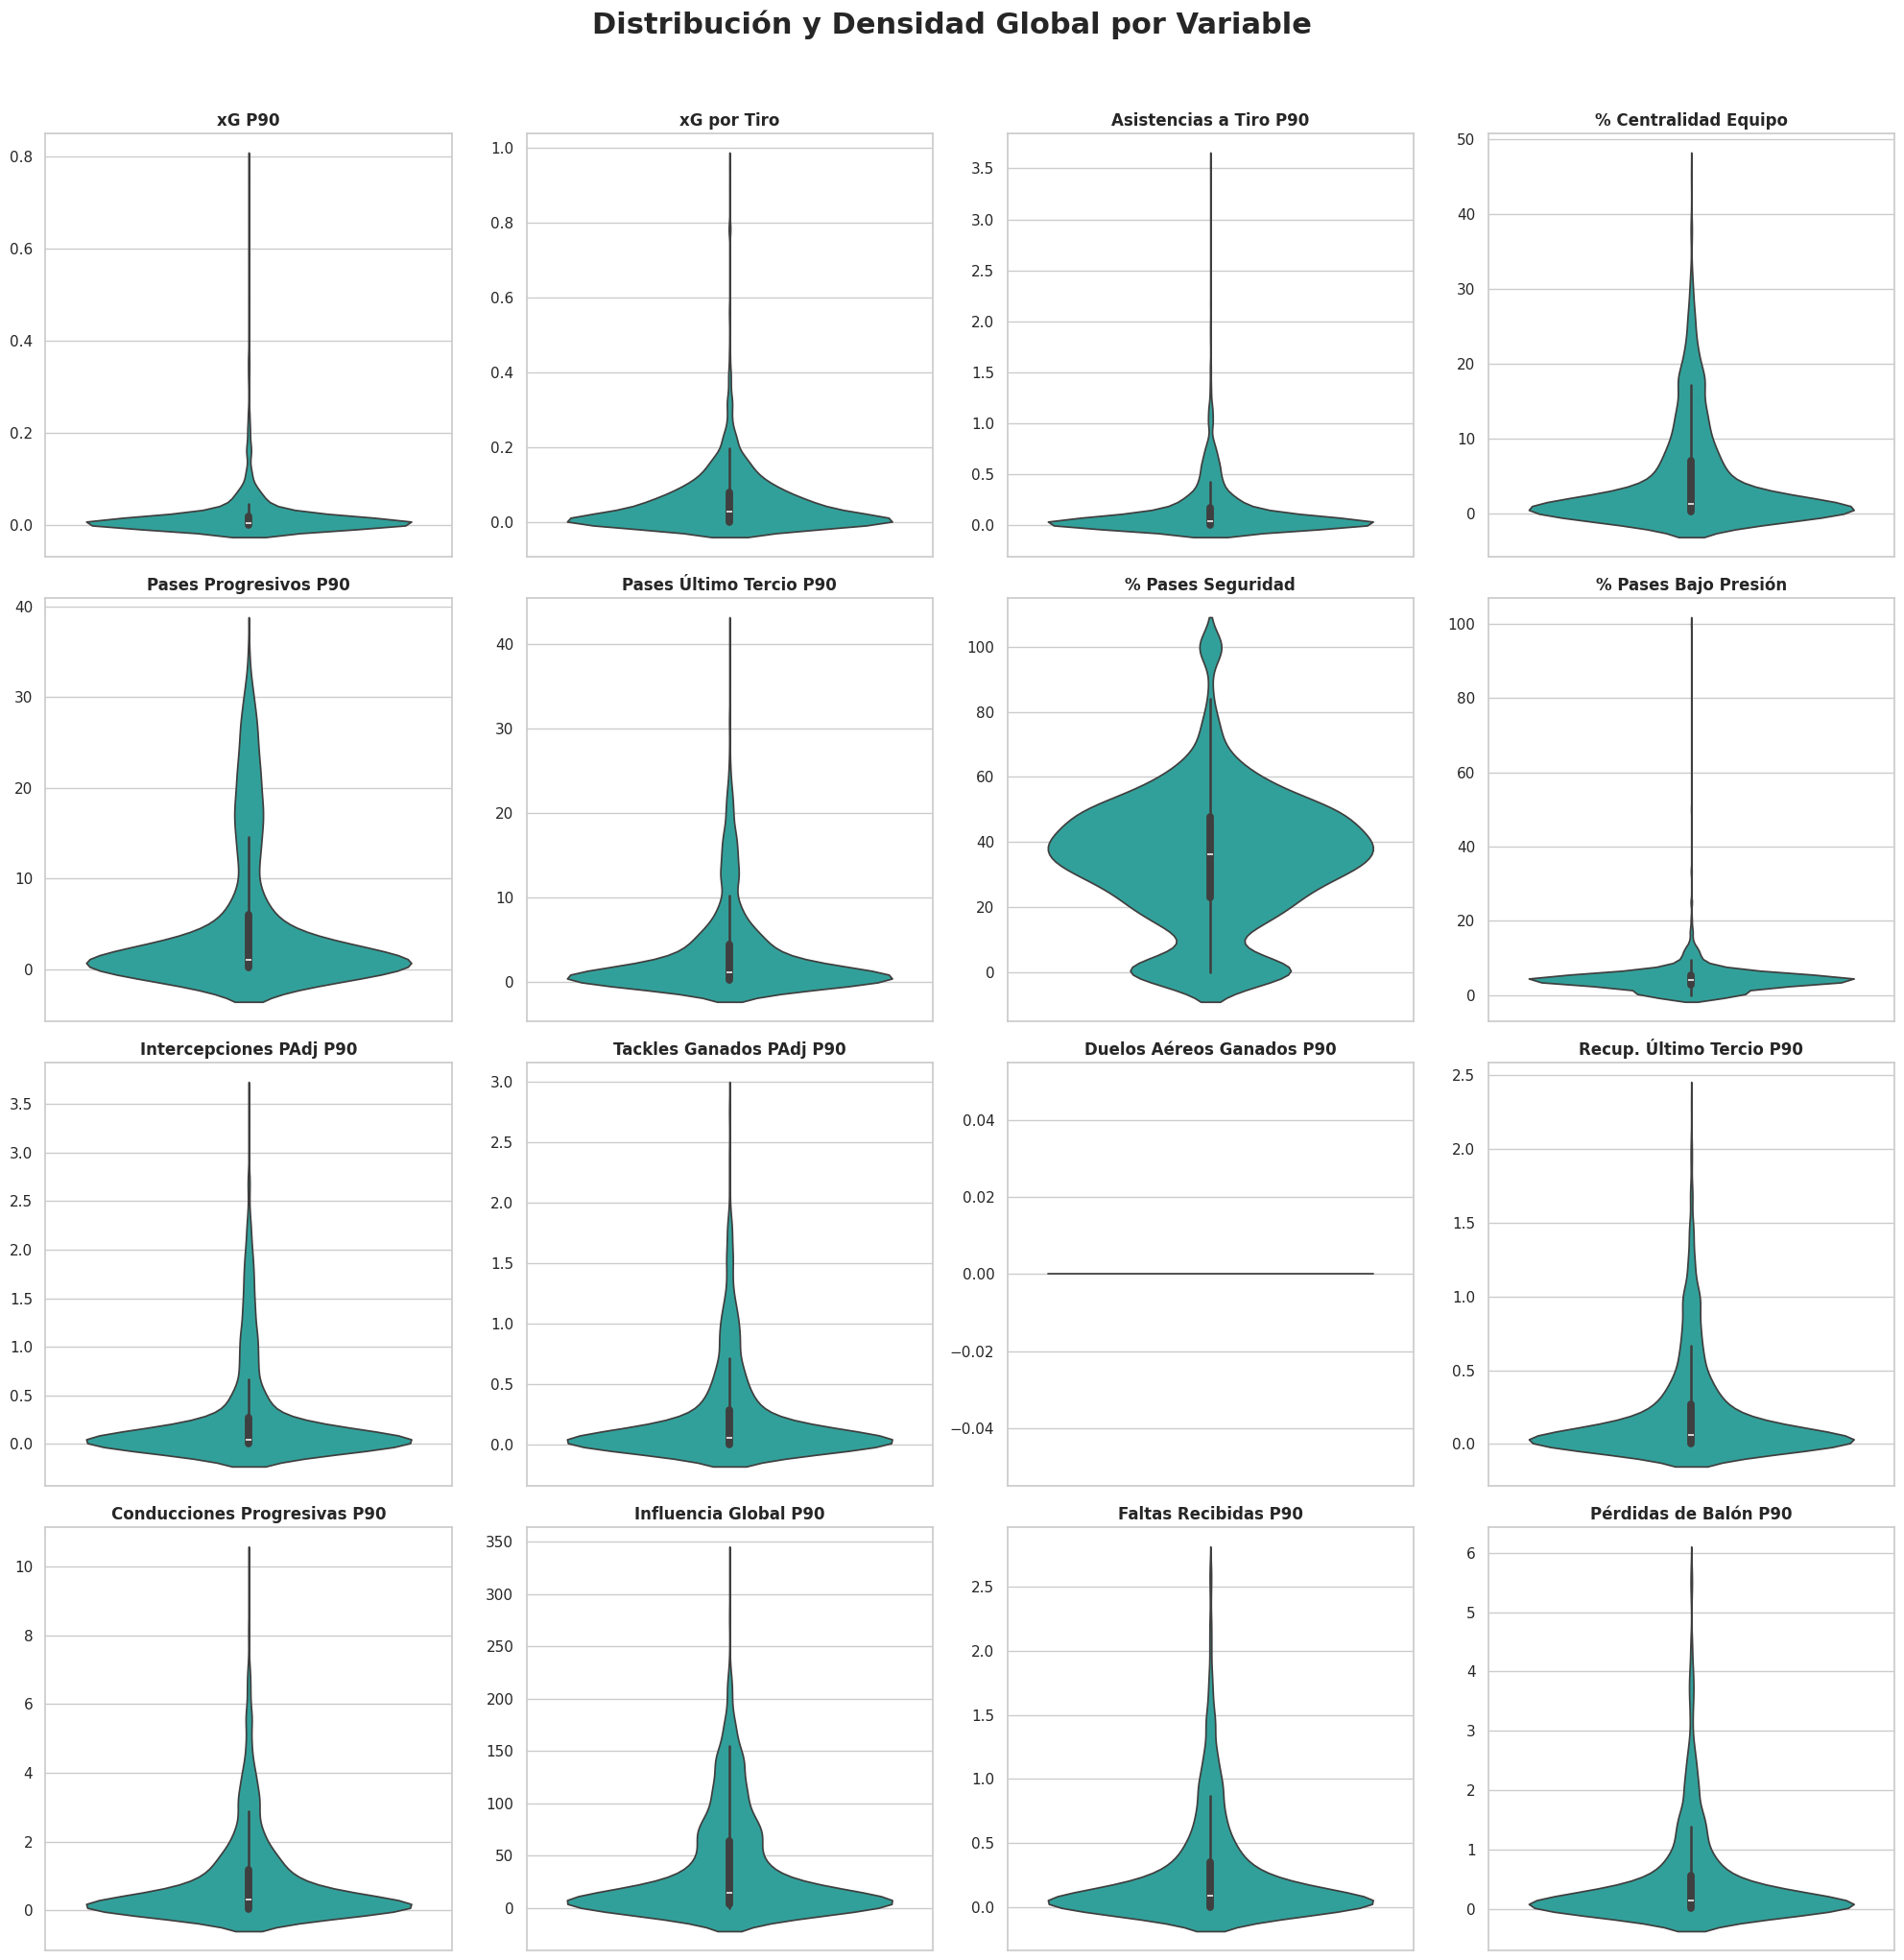

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

print("="*100)
print(" 📊 ESTADÍSTICAS DESCRIPTIVAS: UNIVERSO GLOBAL DE JUGADORES")
print("="*100)

# Definir las 16 columnas métricas del modelo
columnas_modelo = [
    'xG P90', 'xG por Tiro', 'Asistencias a Tiro P90',
    '% Centralidad Equipo', 'Pases Progresivos P90', 'Pases Último Tercio P90',
    '% Pases Seguridad', '% Pases Bajo Presión',
    'Intercepciones PAdj P90', 'Tackles Ganados PAdj P90',
    'Duelos Aéreos Ganados P90', 'Recup. Último Tercio P90',
    'Conducciones Progresivas P90', 'Influencia Global P90',
    'Faltas Recibidas P90', 'Pérdidas de Balón P90'
]

# Generar el resumen estadístico con la función describe() transpuesta para mejor lectura
resumen_total = df_modelo_final[columnas_modelo].describe().T

# Agregar columna de valores nulos como control de calidad
resumen_total['Valores Nulos'] = df_modelo_final[columnas_modelo].isnull().sum()

# Reordenar las columnas de forma analítica
resumen_total = resumen_total[['Valores Nulos', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]

# Renombrar en español para el reporte
resumen_total.columns = [
    'Nulos', 'Conteo', 'Promedio', 'Desv. Estándar',
    'Mínimo', 'Q1 (25%)', 'Mediana (50%)', 'Q3 (75%)', 'Máximo'
]

# 1. Mostrar la tabla de estadísticas
display(resumen_total.round(3))

# ==============================================================================
# 2. VISUALIZACIÓN GLOBAL: VIOLIN PLOTS DE DENSIDAD
# ==============================================================================
print("\n" + "="*100)
print(" 🎻 DISTRIBUCIÓN GLOBAL DE LAS MÉTRICAS (VIOLIN PLOTS)")
print("="*100)

# Configuración visual
sns.set_theme(style="whitegrid")

# Crear el lienzo 4x4
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
fig.suptitle('Distribución y Densidad Global por Variable', fontsize=22, y=1.02, fontweight='bold')
axes = axes.flatten()

# Generar un Violin Plot vertical para cada variable en el universo global
for i, col in enumerate(columnas_modelo):
    sns.violinplot(y=df_modelo_final[col], ax=axes[i], color='lightseagreen', inner='box')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

## 3. Comparación Táctica por Liga y Análisis de Valores Atípicos (Outliers)

Tras comprender el comportamiento global, el siguiente paso metodológico es segmentar la información por competición (Premier League, La Liga, Serie A, Ligue 1) para evaluar si existen diferencias estructurales que puedan sesgar nuestro futuro modelo. Para ello, combinamos tres técnicas:
1.  **Promedios y Volatilidad:** Tablas cruzadas para identificar tendencias generales.
2.  **Gráficos de Violín por Liga:** Para comparar visualmente la forma de las densidades y la dispersión.
3.  **Extracción de Extremos (Top 3):** Identificación directa de los jugadores que empujan las colas de las distribuciones.

### 🟢 Luz Verde Estadística: Homogeneidad Estructural
El hallazgo más importante de los *Violin Plots* segmentados es que **no existen diferencias drásticas en la densidad entre las ligas**. La "pancita" (el grueso de la población) y el comportamiento de las métricas siguen la misma distribución matemática en Inglaterra, España, Italia y Francia.

Esta es una excelente noticia para el modelado: significa que el fútbol de élite europeo funciona como un ecosistema táctico homogéneo. Al no existir un sesgo masivo por liga, tenemos la justificación estadística perfecta para aplicar una **Estandarización Global** en nuestro Análisis de Componentes Principales (PCA), sin necesidad de aislar los datos por país.

### 🌟 Hallazgos en la Élite: Los Atípicos que Rompen el Molde
Aunque el promedio es similar, las diferencias reales entre ligas las marcan los superestrellas (las colas largas de los gráficos). La extracción de los valores máximos revela anomalías estadísticas fascinantes:

*   **El Olimpo del Gol (xG P90):** Solo cuatro jugadores en toda Europa lograron superar la barrera de 0.70 goles esperados por partido, conformando la élite absoluta de la temporada: Luis Suárez (0.78), Karim Benzema (0.75), Zlatan Ibrahimović (0.73) y Gonzalo Higuaín (0.70).
*   **Los Francotiradores (xG por Tiro):** Un hallazgo sumamente interesante ocurre con el jugador Souleymane Camara (Montpellier), quien registra un asombroso **0.94** de xG por cada tiro, seguido por Gonzalo Escalante (Eibar) con **0.88**. Esto indica que prácticamente cada vez que dispararon a puerta, era un gol inminente (posiblemente porque solo dispararon en situaciones de arco vacío a lo largo de sus minutos jugados). El resto de la élite europea cae bruscamente por debajo del 0.8.
*   **El Dominio Absoluto de Mesut Özil:** El alemán representa una anomalía estadística sin igual en la creación de juego. Registró **3.53 Asistencias a Tiro P90**, destruyendo al segundo mejor de Europa (Marek Hamšík con 2.17). Además, es el único jugador en superar los 40 Pases al Último Tercio por partido.
*   **El Motor del Napoli (Influencia Global):** Jorge Luiz Frello (Jorginho) es el único jugador en Europa en superar las 300 acciones por partido (322.8), seguido en el top general por su compañero Marek Hamšík (270.9). Esto no solo habla del jugador, sino del sistema táctico de posesión extrema del Napoli de esa temporada.
*   **Casos de Nicho y Métricas Estándar:** Vemos rarezas posicionales como el defensa Aaron Cresswell, único en superar el 45% de Centralidad de Equipo, y a Iván Ramis con un 100% de Pases Bajo Presión (una anomalía que requiere contexto, pues probablemente intentó muy pocos pases en toda la temporada). Por otro lado, las métricas defensivas (Intercepciones, Tackles) y de errores (Pérdidas de Balón) mostraron techos consistentes entre ligas, sin anomalías que destaquen sobre el resto.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print(" 🌍 COMPARACIÓN TÁCTICA: PROMEDIOS MÉTRICOS POR LIGA")
print("="*80)

# Agrupar los datos por el nombre de la liga y calcular la media de las variables
resumen_liga_media = df_modelo_final.groupby('competition_name')[columnas_modelo].mean().T

# Ordenar las ligas alfabéticamente en las columnas para estandarizar la vista
resumen_liga_media = resumen_liga_media.sort_index(axis=1)

# Desplegar el DataFrame comparativo
display(resumen_liga_media.round(3))

print("\n" + "="*80)
print(" 🔍 COMPARACIÓN DE VOLATILIDAD: DESVIACIÓN ESTÁNDAR POR LIGA")
print("="*80)

# (Opcional) Ver la dispersión: ¿En qué liga hay más desigualdad entre los jugadores top y el resto?
resumen_liga_std = df_modelo_final.groupby('competition_name')[columnas_modelo].std().T
resumen_liga_std = resumen_liga_std.sort_index(axis=1)

display(resumen_liga_std.round(3))


 🌍 COMPARACIÓN TÁCTICA: PROMEDIOS MÉTRICOS POR LIGA


competition_name,La Liga,Ligue 1,Premier League,Serie A
xG P90,0.021,0.018,0.025,0.023
xG por Tiro,0.056,0.058,0.055,0.056
Asistencias a Tiro P90,0.128,0.129,0.169,0.154
% Centralidad Equipo,4.963,4.701,4.975,4.695
Pases Progresivos P90,5.101,5.061,5.558,4.968
Pases Último Tercio P90,3.464,3.140,3.991,3.099
% Pases Seguridad,34.234,34.503,36.045,35.308
% Pases Bajo Presión,4.218,4.558,4.352,4.499
Intercepciones PAdj P90,0.365,0.254,0.286,0.224
Tackles Ganados PAdj P90,0.244,0.234,0.253,0.219



 🔍 COMPARACIÓN DE VOLATILIDAD: DESVIACIÓN ESTÁNDAR POR LIGA


competition_name,La Liga,Ligue 1,Premier League,Serie A
xG P90,0.069,0.050,0.057,0.062
xG por Tiro,0.085,0.097,0.069,0.091
Asistencias a Tiro P90,0.233,0.221,0.308,0.282
% Centralidad Equipo,7.485,6.256,6.772,6.890
Pases Progresivos P90,8.110,7.554,8.454,7.990
Pases Último Tercio P90,5.487,4.454,5.738,4.941
% Pases Seguridad,20.104,19.331,21.317,20.634
% Pases Bajo Presión,5.818,2.827,3.362,3.647
Intercepciones PAdj P90,0.642,0.440,0.520,0.416
Tackles Ganados PAdj P90,0.416,0.378,0.427,0.393


 🎻 COMPARACIÓN DE DISTRIBUCIONES Y DENSIDAD POR LIGA


/tmp/ipykernel_704/997604965.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_modelo_final, x=col, y='competition_name', ax=axes[i], palette='Set3', inner='box')
/tmp/ipykernel_704/997604965.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_modelo_final, x=col, y='competition_name', ax=axes[i], palette='Set3', inner='box')
/tmp/ipykernel_704/997604965.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_modelo_final, x=col, y='competition_name', ax=axes[i], palette='Set3', inner='box')
/tmp/ipykernel_7

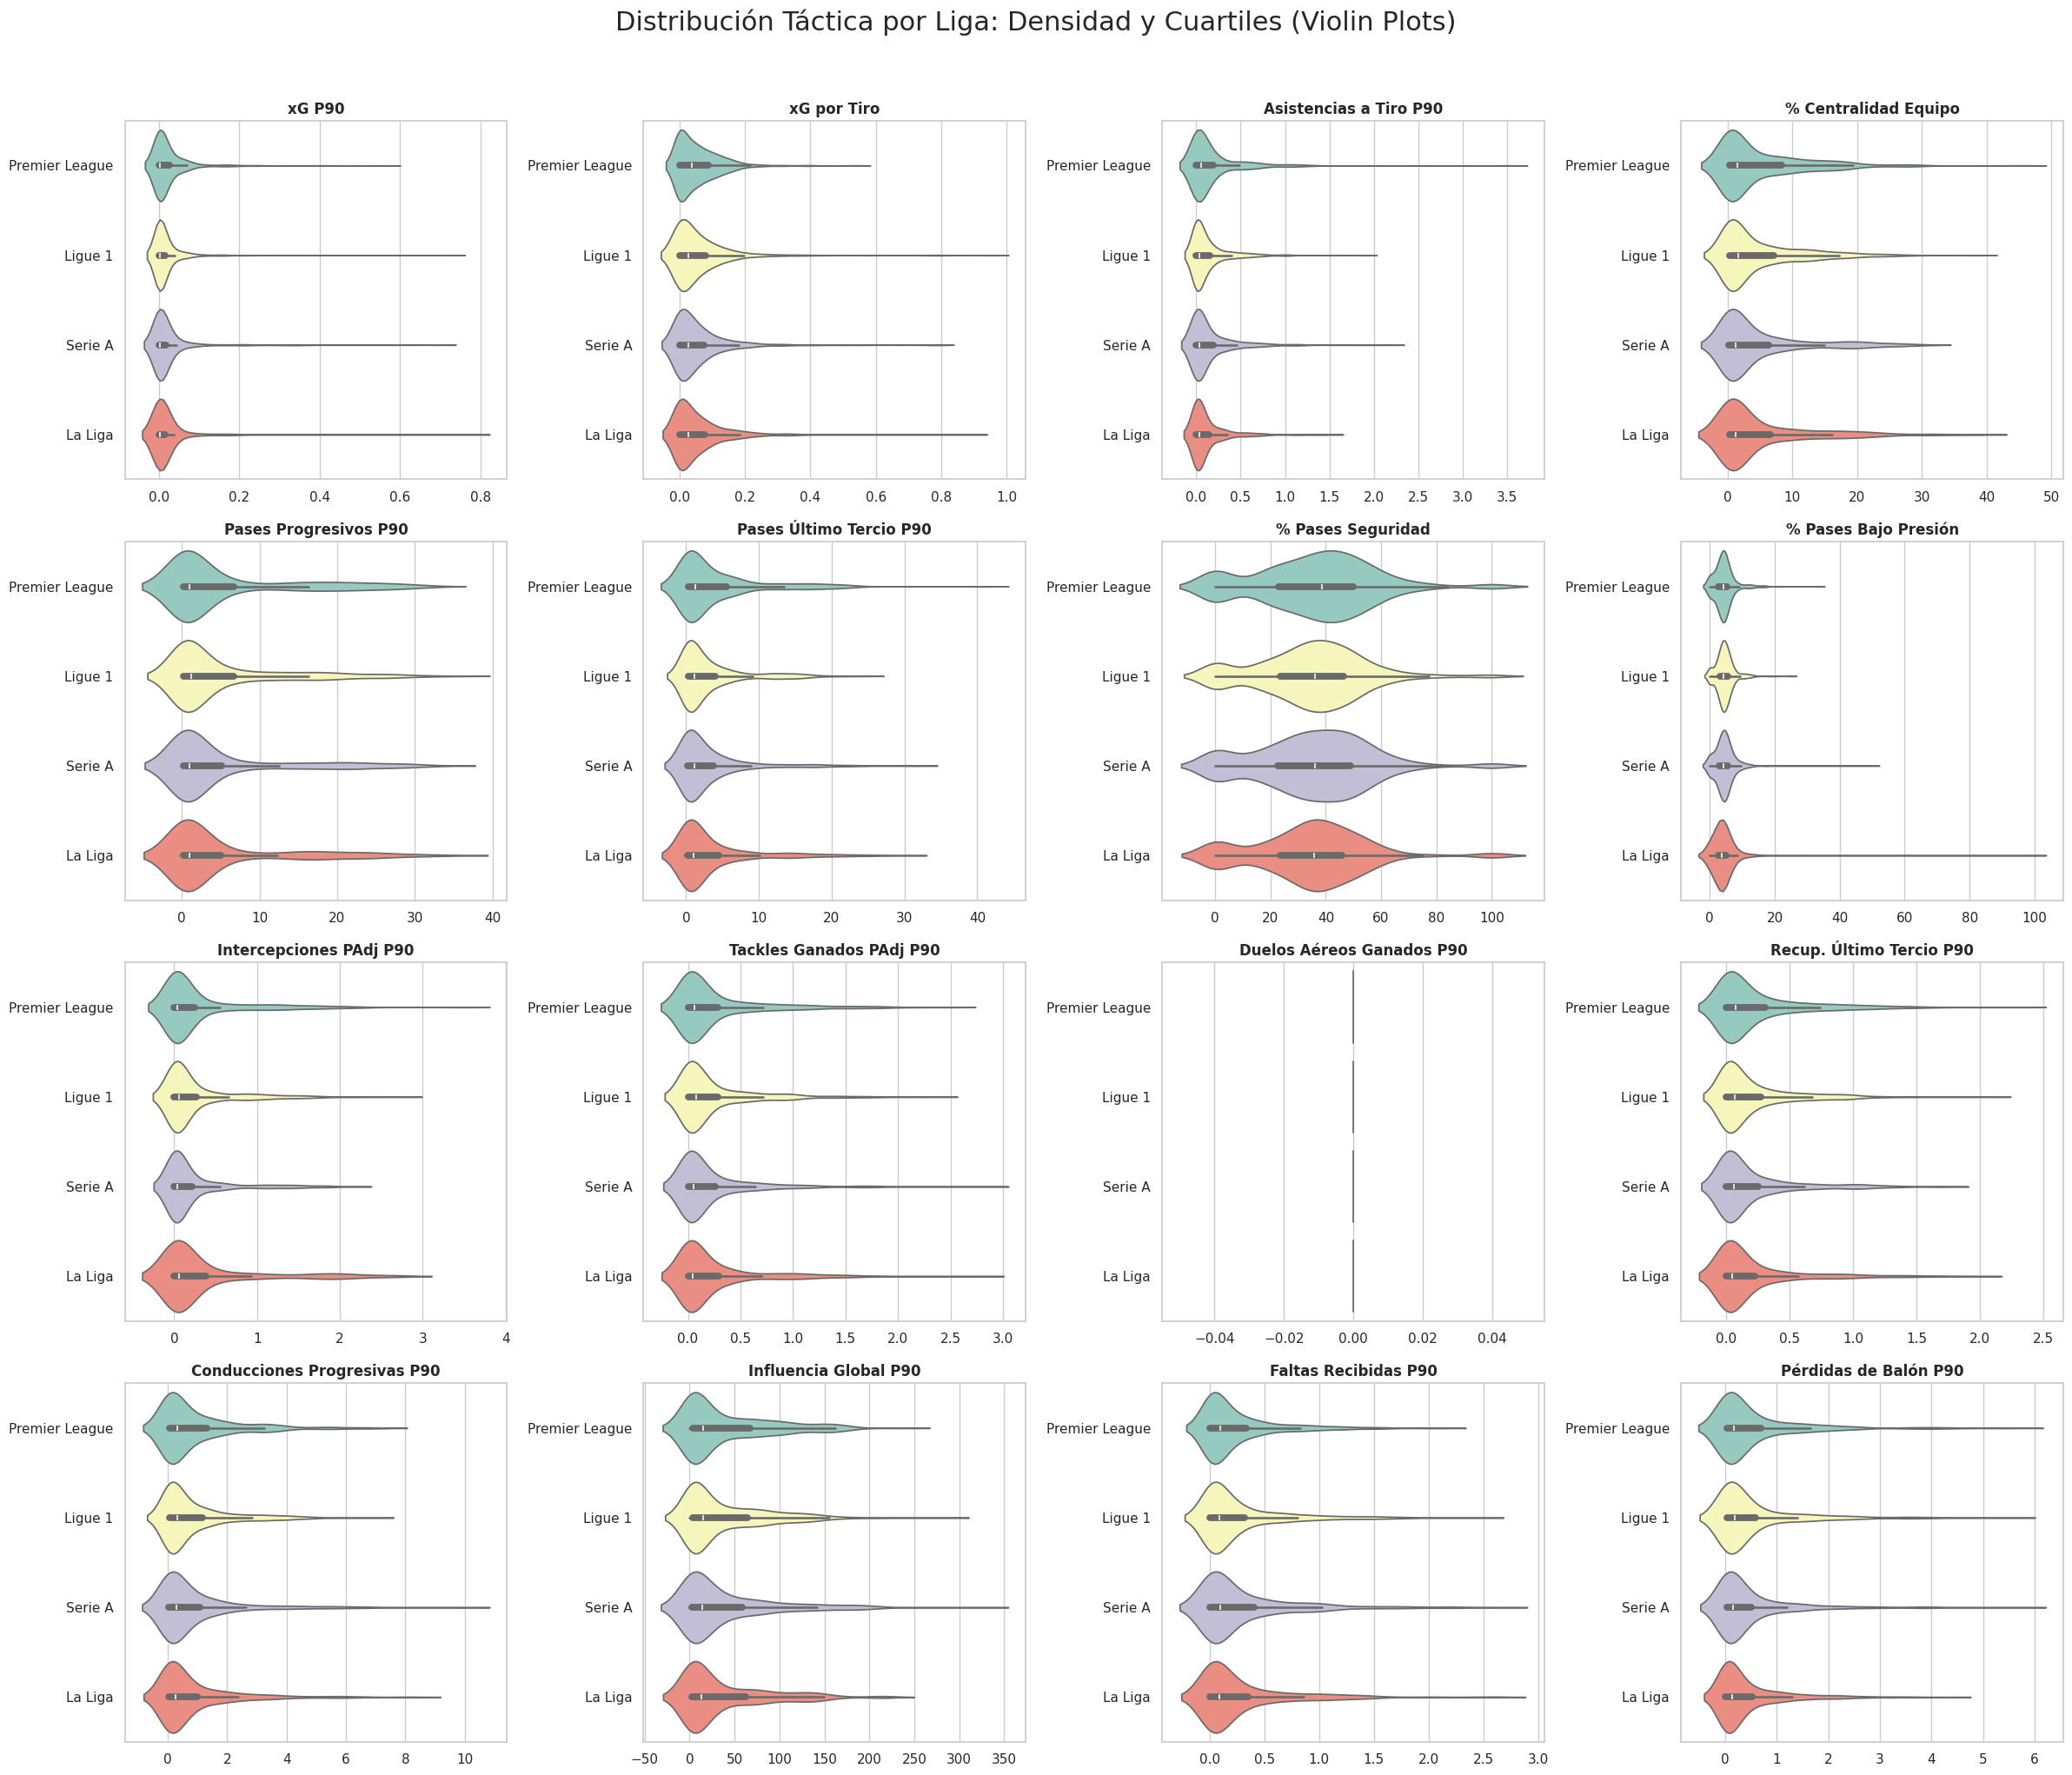

In [ ]:

print("="*80)
print(" 🎻 COMPARACIÓN DE DISTRIBUCIONES Y DENSIDAD POR LIGA")
print("="*80)

# Configuración visual
sns.set_theme(style="whitegrid")

# Crear el lienzo 4x4
fig, axes = plt.subplots(4, 4, figsize=(24, 20))
fig.suptitle('Distribución Táctica por Liga: Densidad y Cuartiles (Violin Plots)', fontsize=22, y=1.02)
axes = axes.flatten()

# Generar un Violin Plot para cada variable
for i, col in enumerate(columnas_modelo):
    # inner='box' dibuja el boxplot en miniatura dentro del violín
    sns.violinplot(data=df_modelo_final, x=col, y='competition_name', ax=axes[i], palette='Set3', inner='box')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()



In [ ]:
import pandas as pd
from IPython.display import display

print("="*80)
print(" 🌟 IDENTIFICACIÓN DE ATÍPICOS EXTREMOS POR LIGA (TOP 3)")
print("="*80)

columnas_contexto = ['player', 'team', 'competition_name', 'position_group']

# Iteramos sobre cada variable para buscar a los atípicos
for col in columnas_modelo:
    print(f"\n" + "-"*60)
    print(f" ⚽ Métrica Analizada: {col}")
    print("-" * 60)

    # Agrupamos por liga y extraemos los 3 valores más altos
    top_por_liga = (
        df_modelo_final
        .groupby('competition_name', group_keys=False)
        .apply(lambda x: x.nlargest(3, col))
    )[columnas_contexto + [col]]

    # Ordenamos visualmente primero por liga y luego por la métrica de mayor a menor
    top_por_liga = top_por_liga.sort_values(by=['competition_name', col], ascending=[True, False])

    # Ocultamos el índice original para que la tabla sea más limpia
    display(top_por_liga.reset_index(drop=True))

 🌟 IDENTIFICACIÓN DE ATÍPICOS EXTREMOS POR LIGA (TOP 3)

------------------------------------------------------------
 ⚽ Métrica Analizada: xG P90
------------------------------------------------------------


/tmp/ipykernel_704/1342551350.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(3, col))


,player,team,competition_name,position_group,xG P90
0,Luis Alberto Suárez Díaz,Barcelona,La Liga,Delantero,0.781681
1,Karim Benzema,Real Madrid,La Liga,Delantero,0.757823
2,Imanol Agirretxe Arruti,Real Sociedad,La Liga,Delantero,0.456615
3,Zlatan Ibrahimović,Paris Saint-Germain,Ligue 1,Delantero,0.732129
4,Michy Batshuayi Tunga,Olympique de Marseille,Ligue 1,Delantero,0.355751
5,Andy Delort,Stade Malherbe Caen,Ligue 1,Delantero,0.312412
6,Harry Kane,Tottenham Hotspur,Premier League,Delantero,0.566045
7,Romelu Lukaku Menama,Everton,Premier League,Delantero,0.445564
8,Sergio Leonel Agüero del Castillo,Manchester City,Premier League,Delantero,0.396951
9,Gonzalo Gerardo Higuaín,Napoli,Serie A,Delantero,0.701897



------------------------------------------------------------
 ⚽ Métrica Analizada: xG por Tiro
------------------------------------------------------------


/tmp/ipykernel_704/1342551350.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(3, col))


...

/tmp/ipykernel_704/1342551350.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(3, col))


,player,team,competition_name,position_group,Faltas Recibidas P90
0,Daniel Arnaud N''Di\t,Sporting Gijón,La Liga,Mediocampista,2.625342
1,Raúl García Escudero,Athletic Club,La Liga,Mediocampista,2.608205
2,Éver Maximiliano David Banega,Sevilla,La Liga,Mediocampista,2.447790
3,Lamine Gassama,Lorient,Ligue 1,Defensa,2.455438
4,William Matheus da Silva,Toulouse,Ligue 1,Defensa,1.839623
5,Wilfried Moimbé,Nantes,Ligue 1,Defensa,1.817502
6,Brendan Joel Zibusiso Galloway,Everton,Premier League,Defensa,2.124312
7,Danny Rose,Tottenham Hotspur,Premier League,Defensa,1.988035
8,Ross Barkley,Everton,Premier League,Mediocampista,1.650871
9,Mário Rui Silva Duarte,Empoli,Serie A,Defensa,2.625564



------------------------------------------------------------
 ⚽ Métrica Analizada: Pérdidas de Balón P90
------------------------------------------------------------


/tmp/ipykernel_704/1342551350.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(3, col))


,player,team,competition_name,position_group,Pérdidas de Balón P90
0,Daniel Arnaud N''Di\t,Sporting Gijón,La Liga,Mediocampista,4.348222
1,Luis Alberto Suárez Díaz,Barcelona,La Liga,Delantero,3.662461
2,Raúl García Escudero,Athletic Club,La Liga,Mediocampista,3.556643
3,Andy Delort,Stade Malherbe Caen,Ligue 1,Delantero,5.513563
4,Maxime Barthelmé,Lorient,Ligue 1,Mediocampista,5.422886
5,Lacina Traoré,AS Monaco,Ligue 1,Delantero,4.554656
6,Romelu Lukaku Menama,Everton,Premier League,Delantero,5.643654
7,Harry Kane,Tottenham Hotspur,Premier League,Delantero,5.180233
8,Sergio Leonel Agüero del Castillo,Manchester City,Premier League,Delantero,4.551387
9,Riccardo Saponara,Empoli,Serie A,Mediocampista,5.736264


## 4. Segmentación Táctica por Posición: La Prueba de Fuego

A diferencia de la comparación por ligas, donde buscábamos homogeneidad, al segmentar por `position_group` (Defensas, Delanteros, Mediocampistas y Porteros) **esperamos encontrar diferencias abismales**. Si el modelo matemático no logra diferenciar a un central de un extremo basado en estos promedios, el futuro algoritmo (PCA) fracasará.

Afortunadamente, el análisis descriptivo y de variabilidad confirma que nuestras 16 métricas capturan la esencia pura de los roles tácticos del fútbol:

### 🎯 1. Finalización y Creación (El monopolio del área)
*   **xG P90 y xG por Tiro:** Como dicta la lógica, los Delanteros dominan absolutamente estas métricas (0.089 xG P90 frente a los 0.013 de los defensas), exhibiendo también la mayor volatilidad (desviación estándar). Esto refleja que la ocasión de gol es un recurso altamente concentrado en pocos jugadores. Los porteros, naturalmente, registran valores nulos.
*   **Asistencias a Tiro:** Curiosamente, es una estadística mucho más democrática. Defensas, Delanteros y Mediocampistas rondan valores muy similares (0.13 a 0.17), lo que demuestra que el último pase antes del tiro puede provenir de laterales ofensivos, mediapuntas o extremos indistintamente.

### 🏗️ 2. Construcción y Progresión (Desde el fondo)
*   **Influencia y Centralidad:** La participación en el juego crece a medida que retrocedemos en el campo. Los Porteros (14.1%) y Defensas (7.5%) duplican o triplican la centralidad de los jugadores de ataque. Las jugadas nacen desde atrás.
*   **Pases Progresivos y al Último Tercio:** Los reyes de la progresión son los Porteros (24.5) y Defensas (7.9). Al estar en la base de la jugada, la inmensa mayoría de sus pases van hacia adelante. Sin embargo, la **alta desviación estándar** en estas posiciones nos indica algo vital para el futuro modelo: hay defensas que rompen líneas constantemente y otros que no progresan en absoluto. El PCA se hará un festín separando estos perfiles.

### 🛡️ 3. El Paradigma de la Presión y la Seguridad
*   **La paradoja del Pase de Seguridad:** Los Delanteros lideran esta métrica con un altísimo 49.7%, mientras que los Porteros apenas registran un 0.5%. Esto ocurre porque, a medida que el equipo avanza en el campo, los espacios se reducen y romper la última línea rival es sumamente difícil. El atacante suele verse obligado a tocar hacia atrás (pase de seguridad) para mantener la posesión.
*   **Conducciones Progresivas:** Rompiendo el mito de que los atacantes conducen más, los datos muestran que los Defensas (1.56) avanzan mucho más metros con el balón dominado que los Delanteros (0.53). El central tiene el espacio físico para salir jugando, mientras que el punta recibe sin espacio y bajo marca férrea.

### ⚔️ 4. Destrucción y Toma de Riesgos
*   **Pérdidas de Balón:** Los Delanteros (1.17) lideran cómodamente las pérdidas. Es el precio natural que asumen los roles creativos al intentar regates, filtrar pases clave o jugar en zonas de máxima densidad rival.
*   **Intercepciones y Tackles vs. Recuperaciones Altas:** La defensa tradicional (tackles/intercepciones) está dominada, como era de esperar, por la línea defensiva. Sin embargo, en la métrica *Recuperaciones en el Último Tercio*, los Delanteros toman el primer lugar, capturando el comportamiento de los equipos que ejercen bloque alto y presión tras pérdida.

In [ ]:
import pandas as pd
from IPython.display import display

print("="*80)
print(" 🛡️ COMPARACIÓN TÁCTICA: PROMEDIOS MÉTRICOS POR POSICIÓN")
print("="*80)

# Calculamos la media de cada métrica agrupada por la posición del jugador
resumen_pos_media = df_modelo_final.groupby('position_group')[columnas_modelo].mean().T

# Ordenamos alfabéticamente las columnas para mantener la consistencia
resumen_pos_media = resumen_pos_media.sort_index(axis=1)

display(resumen_pos_media.round(3))

print("\n" + "="*80)
print(" 🔍 COMPARACIÓN DE VOLATILIDAD: DESVIACIÓN ESTÁNDAR POR POSICIÓN")
print("="*80)

# Calculamos la desviación estándar para ver en qué posición hay más desigualdad
resumen_pos_std = df_modelo_final.groupby('position_group')[columnas_modelo].std().T
resumen_pos_std = resumen_pos_std.sort_index(axis=1)

display(resumen_pos_std.round(3))

 🛡️ COMPARACIÓN TÁCTICA: PROMEDIOS MÉTRICOS POR POSICIÓN


position_group,Defensa,Delantero,Mediocampista,Portero
xG P90,0.013,0.089,0.015,0.000
xG por Tiro,0.048,0.106,0.057,0.003
Asistencias a Tiro P90,0.175,0.177,0.133,0.023
% Centralidad Equipo,7.525,2.274,2.491,14.145
Pases Progresivos P90,7.994,0.986,1.848,24.554
Pases Último Tercio P90,5.511,2.532,2.195,3.822
% Pases Seguridad,28.291,49.778,40.288,0.585
% Pases Bajo Presión,4.218,4.710,4.751,2.206
Intercepciones PAdj P90,0.652,0.059,0.125,0.002
Tackles Ganados PAdj P90,0.454,0.096,0.159,0.001



 🔍 COMPARACIÓN DE VOLATILIDAD: DESVIACIÓN ESTÁNDAR POR POSICIÓN


position_group,Defensa,Delantero,Mediocampista,Portero
xG P90,0.020,0.143,0.030,0.001
xG por Tiro,0.063,0.112,0.092,0.023
Asistencias a Tiro P90,0.260,0.260,0.275,0.032
% Centralidad Equipo,8.240,3.339,4.223,7.359
Pases Progresivos P90,8.128,1.471,3.502,6.596
Pases Último Tercio P90,6.772,3.543,3.950,2.262
% Pases Seguridad,15.342,20.180,18.016,0.748
% Pases Bajo Presión,5.302,3.517,3.258,0.965
Intercepciones PAdj P90,0.703,0.090,0.257,0.012
Tackles Ganados PAdj P90,0.522,0.138,0.311,0.006


 🎻 COMPARACIÓN DE DISTRIBUCIONES Y DENSIDAD POR POSICIÓN


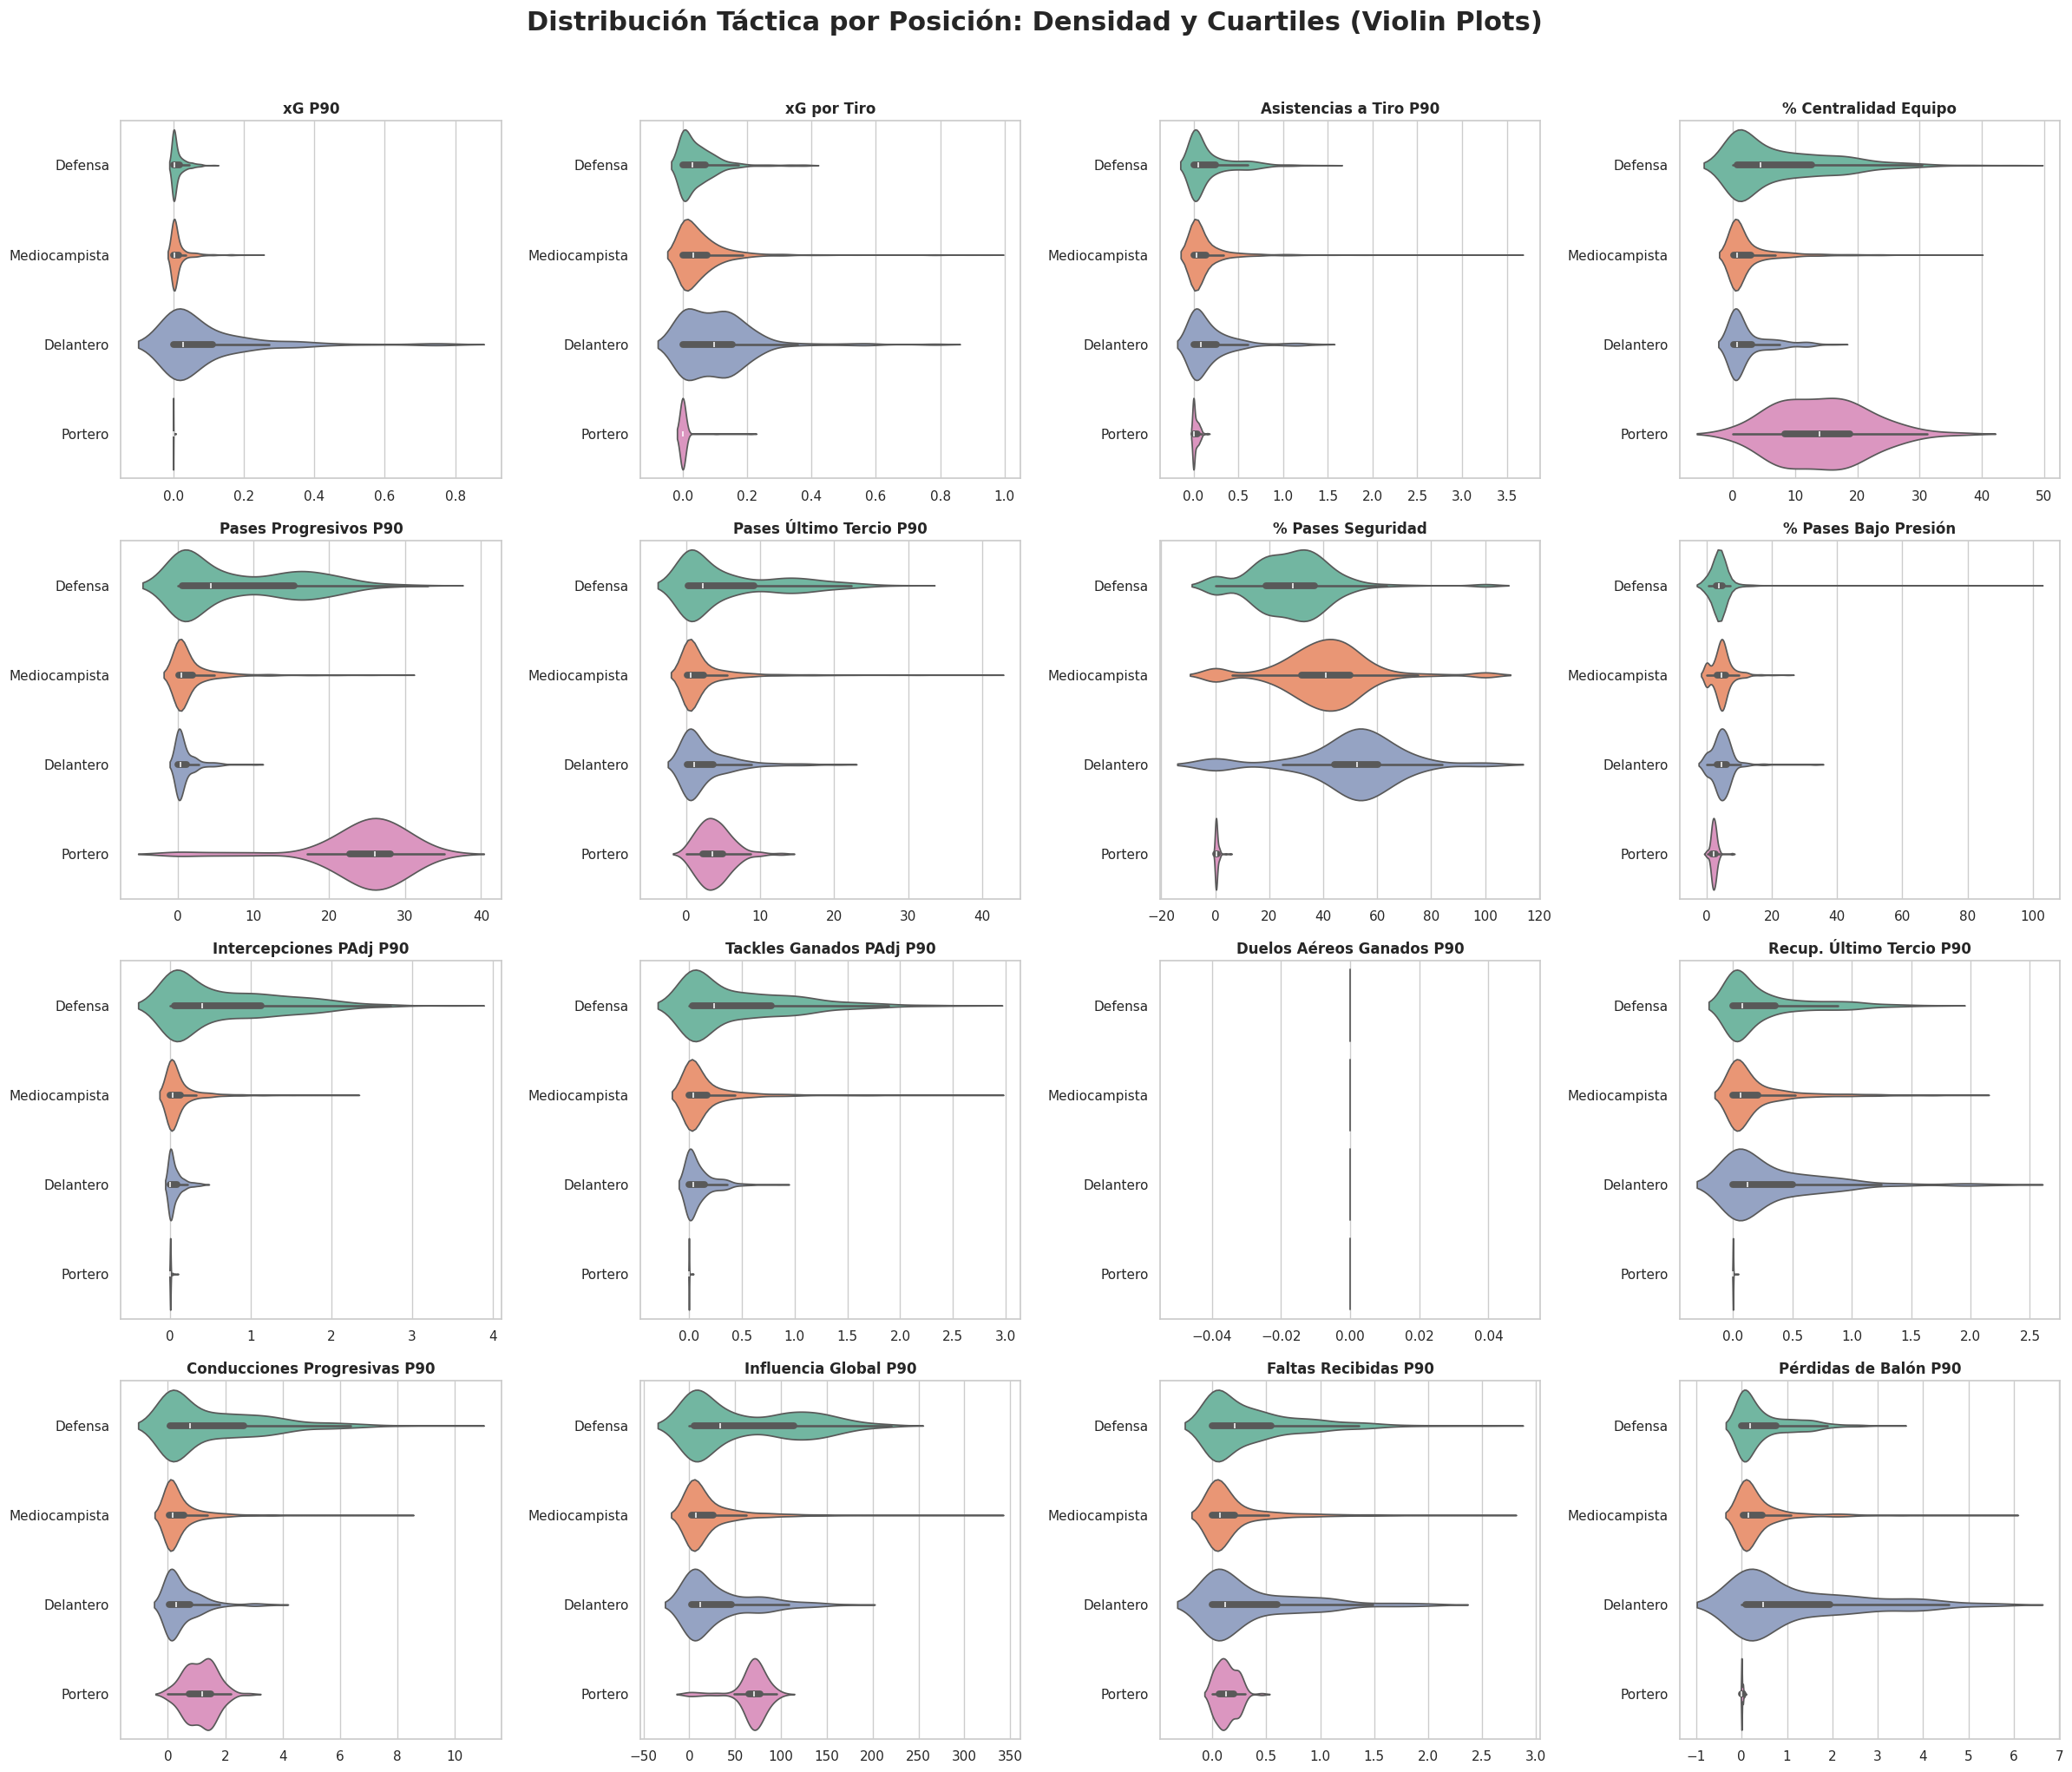

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print(" 🎻 COMPARACIÓN DE DISTRIBUCIONES Y DENSIDAD POR POSICIÓN")
print("="*80)

# Configuración visual
sns.set_theme(style="whitegrid")

# Crear el lienzo 4x4
fig, axes = plt.subplots(4, 4, figsize=(24, 20))
fig.suptitle('Distribución Táctica por Posición: Densidad y Cuartiles (Violin Plots)', fontsize=22, y=1.02, fontweight='bold')
axes = axes.flatten()

# Generar un Violin Plot para cada variable
for i, col in enumerate(columnas_modelo):
    sns.violinplot(
        data=df_modelo_final,
        x=col,
        y='position_group',
        hue='position_group',
        ax=axes[i],
        palette='Set2',
        inner='box',
        legend=False
    )
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()